# FPN-Mamba Experiments — A100 80GB Colab Runner

**Before starting:** Runtime → Change runtime type → A100 GPU.

**Run order:** Cell 1 → 2 → 3 → 4 → 5 (wandb) → 5.5 (delete stale results) → 6 → 7 → 8 → 9 → 10 → 11 → 12 (Fig. 2) → 13 → 14 (commit to git)

## Cell 1 — Verify A100 GPU

In [ ]:
import torch

assert torch.cuda.is_available(), 'No GPU. Runtime -> Change runtime type -> GPU -> A100'
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
bf16_ok  = torch.cuda.is_bf16_supported()

print(f'GPU  : {gpu_name}')
print(f'VRAM : {vram_gb:.1f} GB')
print(f'BF16 : {bf16_ok}  (True = A100 confirmed -- bfloat16 auto-enabled in trainer)')

if not bf16_ok:
    print('WARNING: Not an A100. Reduce batch sizes below if you get OOM.')

GPU  : NVIDIA A100-SXM4-80GB
VRAM : 85.1 GB
BF16 : True  (True = A100 confirmed -- bfloat16 auto-enabled in trainer)


## Cell 2 — Mount Google Drive

Checkpoints and results save here. Code and data come from GitHub, not Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_RESULTS = '/content/drive/MyDrive/fpn_mamba/experiments'
os.makedirs(DRIVE_RESULTS, exist_ok=True)
print('Drive mounted. Results ->', DRIVE_RESULTS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Results -> /content/drive/MyDrive/fpn_mamba/experiments


## Cell 3 — Clone Repo from GitHub

The dataset (4457 images) is committed in the repo — no separate download needed.

In [ ]:
import os, sys

REPO_URL = 'https://github.com/Tech-sam-90/fpn-inceptentionnet'
REPO_DIR = '/content/fpn-inceptentionnet'
BRANCH   = 'version_2'

if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} checkout {BRANCH}
    !git -C {REPO_DIR} pull origin {BRANCH}

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

DATA_ROOT = f'{REPO_DIR}/data'
classes   = sorted(d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d)))
n_images  = sum(len(os.listdir(os.path.join(DATA_ROOT, c))) for c in classes)

print(f'Repo    : {REPO_DIR}  (branch: {BRANCH})')
print(f'Data    : {DATA_ROOT}')
print(f'Classes : {classes}')
print(f'Images  : {n_images}')
!git log --oneline -3

Cloning into '/content/fpn-inceptentionnet'...
remote: Enumerating objects: 4848, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 4848 (delta 141), reused 149 (delta 76), pack-reused 4627 (from 2)
Receiving objects: 100% (4848/4848), 262.42 MiB | 34.61 MiB/s, done.
Resolving deltas: 100% (191/191), done.
Updating files: 100% (4554/4554), done.
Repo    : /content/fpn-inceptentionnet  (branch: version_2)
Data    : /content/fpn-inceptentionnet/data
Classes : ['Astrocitoma', 'Carcinoma', 'Ependimoma', 'Ganglioglioma', 'Germinoma', 'Glioblastoma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Normal', 'Oligodendroglioma', 'Papiloma', 'Schwannoma', 'Tuberculoma']
Images  : 4456
4a6ac28 (HEAD -> version_2, origin/version_2) Stabilize calibration-based threshold selection
855902f Add calibration-split diagnostic cell to Colab runner
7b8f37c Fix validation-leakage in CV protocol via nested calibration split


## Cell 4 — Install Dependencies

In [ ]:
!pip install -q timm einops scikit-learn scipy thop pyyaml tqdm matplotlib seaborn pandas wandb
print('Done.')

Done.


## Cell 5 — Weights & Biases Login

Paste your API key below. **Do not push this cell's key to GitHub.**
This cell runs only in Colab — the key never leaves your session.

In [ ]:
import wandb

WANDB_API_KEY = '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'  # <-- replace with your key

wandb.login(key=WANDB_API_KEY, relogin=True)
print('wandb logged in. Project: medulloblastoma-classification')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sadeniji to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb logged in. Project: medulloblastoma-classification


## Config Helper

Sets A100 80GB batch sizes: InceptentionNet stays at 8 (paper-exact), FPN-Mamba and ablation use 64.

In [ ]:
import yaml
from pathlib import Path

def make_config(yaml_path: str, overrides: dict) -> str:
    def _deep_update(base, patch):
        for k, v in patch.items():
            if isinstance(v, dict) and k in base:
                _deep_update(base[k], v)
            else:
                base[k] = v
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    _deep_update(cfg, overrides)
    out = f'/tmp/{Path(yaml_path).stem}_patched.yaml'
    with open(out, 'w') as f:
        yaml.dump(cfg, f)
    return out

# Shared overrides for all experiments
A100_BASE = {
    'data':     {'data_root': DATA_ROOT},
    'training': {'num_workers': 4},  # A100 VMs have 12+ CPU cores
}

print('Config helper ready.')
print('  InceptentionNet batch : 8   (paper-exact, do not change)')
print('  FPN-Mamba batch       : 64  (A100 80GB comfortable at 64)')
print('  Ablation batch        : 64')

Config helper ready.
  InceptentionNet batch : 8   (paper-exact, do not change)
  FPN-Mamba batch       : 64  (A100 80GB comfortable at 64)
  Ablation batch        : 64


## Cell 5.5 — Delete Stale Pre-Fix Results (validation-leakage fix)

Wipes every run directory on Drive before retraining under the corrected
(calibration-split) protocol. This is not optional: `run_crossval()` resumes
**per fold** from `fold_{n}_result.json` before it ever rewrites `cv_results.json`,
so deleting only `cv_results.json` would silently reload the old, leaky
per-fold results instead of retraining. Run this once before Cells 6–9.

In [ ]:
import shutil, os

# Every run directory is wiped outright (not just cv_results.json / fold_*.pt)
# because run_crossval() resumes per FOLD from fold_{n}_result.json, before it
# ever re-aggregates cv_results.json. Leaving those per-fold files in place
# would silently reload pre-fix (leaky) results under the new protocol.
STALE_RUN_DIRS = {
    'InceptentionNet': f'{DRIVE_RESULTS}/inceptentionnet',
    'ResNet-50':       f'{DRIVE_RESULTS}/resnet50',
    'FPN-Mamba':       f'{DRIVE_RESULTS}/fpn_mamba',
    'Ablation':        f'{DRIVE_RESULTS}/ablation',
}

print('Wiping pre-fix (validation-leakage) results so nothing gets skipped via [RESUME]...')
for name, run_dir in STALE_RUN_DIRS.items():
    if os.path.exists(run_dir):
        shutil.rmtree(run_dir)
        print(f'  [DELETED] {name:<14} {run_dir}')
    else:
        print(f'  [SKIP]    {name:<14} {run_dir}  (nothing to delete)')

Wiping pre-fix (validation-leakage) results so nothing gets skipped via [RESUME]...
  [DELETED] InceptentionNet /content/drive/MyDrive/fpn_mamba/experiments/inceptentionnet
  [DELETED] ResNet-50      /content/drive/MyDrive/fpn_mamba/experiments/resnet50
  [DELETED] FPN-Mamba      /content/drive/MyDrive/fpn_mamba/experiments/fpn_mamba
  [DELETED] Ablation       /content/drive/MyDrive/fpn_mamba/experiments/ablation


## Cell 6 — Train InceptentionNet Baseline

Paper-exact: LR=0.005, **batch=8**, 40 epochs, patience=10, sigma=2.0, 4x augmentation.
Batch size must stay at 8 to faithfully replicate the paper.

In [ ]:
import os

BASELINE_RUN_DIR = f'{DRIVE_RESULTS}/inceptentionnet'
BASELINE_RESULTS = f'{BASELINE_RUN_DIR}/cv_results.json'

if os.path.exists(BASELINE_RESULTS):
    print('Already done. Delete', BASELINE_RESULTS, 'to retrain.')
else:
    cfg = make_config(
        f'{REPO_DIR}/configs/inceptentionnet.yaml',
        overrides={
            **A100_BASE,
            # batch_size stays at 8 -- paper-exact, do not override
            'output': {'run_dir': BASELINE_RUN_DIR},
        }
    )
    !python scripts/train.py --config {cfg}

print('\nBaseline results:', BASELINE_RESULTS)

Training: inceptentionnet
Run dir : /content/drive/MyDrive/fpn_mamba/experiments/inceptentionnet

Training : inceptentionnet
Device   : cuda (NVIDIA A100-SXM4-80GB)
Run dir  : /content/drive/MyDrive/fpn_mamba/experiments/inceptentionnet
wandb    : enabled

Dataset  : 736 samples  (106 MB / 630 non-MB)

  FOLD 1 / 5   (588 train [incl. calibration split] / 148 held-out)
  [RESUME] Fold 1 already done — loading saved result.

  Fold 1 result -> AUC=0.7197  F1=0.3333  Sens=0.4091  Spec=0.8175  Acc=0.7568  Time=1.8min

  FOLD 2 / 5   (589 train [incl. calibration split] / 147 held-out)
  [RESUME] Fold 2 already done — loading saved result.

  Fold 2 result -> AUC=0.8065  F1=0.3939  Sens=0.6190  Spec=0.7460  Acc=0.7279  Time=1.9min

  FOLD 3 / 5   (589 train [incl. calibration split] / 147 held-out)
  [RESUME] Fold 3 already done — loading saved result.

  Fold 3 result -> AUC=0.7249  F1=0.2899  Sens=0.4762  Spec=0.6984  Acc=0.6667  Time=0.5min

  FOLD 4 / 5   (589 train [incl. calibration 

## Cell 7 — Train ResNet-50

A100 80GB: **batch=64**, timm `resnet50` backbone (ImageNet-pretrained),
freeze_layers=2. Same nested calibration-split protocol as every other model.

In [ ]:
import os

RESNET_RUN_DIR = f'{DRIVE_RESULTS}/resnet50'
RESNET_RESULTS = f'{RESNET_RUN_DIR}/cv_results.json'

if os.path.exists(RESNET_RESULTS):
    print('Already done. Delete', RESNET_RESULTS, 'to retrain.')
else:
    cfg = make_config(
        f'{REPO_DIR}/configs/resnet50.yaml',
        overrides={
            **A100_BASE,
            'training': {'batch_size': 64, 'num_workers': 4},
            'output':   {'run_dir': RESNET_RUN_DIR},
        }
    )
    !python scripts/train.py --config {cfg} --baseline_results {BASELINE_RESULTS}

print('\nResNet-50 results:', RESNET_RESULTS)

Training: resnet50
Run dir : /content/drive/MyDrive/fpn_mamba/experiments/resnet50

Training : resnet50
Device   : cuda (NVIDIA A100-SXM4-80GB)
Run dir  : /content/drive/MyDrive/fpn_mamba/experiments/resnet50
wandb    : enabled

Dataset  : 761 samples  (131 MB / 630 non-MB)

  FOLD 1 / 5   (608 train [incl. calibration split] / 153 held-out)

model.safetensors: downloading bytes:   0% 0.00/102M [00:00<?, ?B/s]
model.safetensors: downloading bytes:   5% 4.61M/102M [00:00<00:19, 5.09MB/s]
model.safetensors: downloading bytes:  42% 43.3M/102M [00:01<00:01, 42.4MB/s, 3.46MB/s  ]
model.safetensors: downloading bytes:  50% 51.3M/102M [00:01<00:01, 48.7MB/s, 4.11MB/s  ]
model.safetensors: downloading bytes:  58% 59.4M/102M [00:01<00:00, 55.0MB/s, 4.85MB/s  ]
model.safetensors: downloading bytes:  77% 78.6M/102M [00:01<00:00, 60.4MB/s, 6.52MB/s  ]
model.safetensors: downloading bytes:  86% 88.5M/102M [00:02<00:00, 68.9MB/s, 7.25MB/s  ]
model.safetensors: downloading bytes: 100% 96.2M/96.2M [00

## Cell 8 — Train FPN-Mamba (Full Model)

A100 80GB: **batch=64**, bfloat16 auto-enabled, num_workers=4.

In [ ]:
import os

FPN_RUN_DIR = f'{DRIVE_RESULTS}/fpn_mamba'
FPN_RESULTS = f'{FPN_RUN_DIR}/cv_results.json'

if os.path.exists(FPN_RESULTS):
    print('Already done. Delete', FPN_RESULTS, 'to retrain.')
else:
    cfg = make_config(
        f'{REPO_DIR}/configs/fpn_mamba.yaml',
        overrides={
            **A100_BASE,
            'training': {'batch_size': 64, 'num_workers': 4},
            'output':   {'run_dir': FPN_RUN_DIR},
        }
    )
    !python scripts/train.py --config {cfg} --baseline_results {BASELINE_RESULTS}

print('\nFPN-Mamba results:', FPN_RESULTS)

Training: fpn_mamba_full
Run dir : /content/drive/MyDrive/fpn_mamba/experiments/fpn_mamba

Training : fpn_mamba_full
Device   : cuda (NVIDIA A100-SXM4-80GB)
Run dir  : /content/drive/MyDrive/fpn_mamba/experiments/fpn_mamba
wandb    : enabled

Dataset  : 761 samples  (131 MB / 630 non-MB)

  FOLD 1 / 5   (608 train [incl. calibration split] / 153 held-out)
  [RESUME] Fold 1 already done — loading saved result.

  Fold 1 result -> AUC=0.9897  F1=0.8846  Sens=0.8519  Spec=0.9841  Acc=0.9608  Time=4.0min

  FOLD 2 / 5   (609 train [incl. calibration split] / 152 held-out)
  [RESUME] Fold 2 already done — loading saved result.

  Fold 2 result -> AUC=0.9896  F1=0.8814  Sens=1.0000  Spec=0.9444  Acc=0.9539  Time=4.0min

  FOLD 3 / 5   (609 train [incl. calibration split] / 152 held-out)
  [RESUME] Fold 3 already done — loading saved result.

  Fold 3 result -> AUC=0.9115  F1=0.6122  Sens=0.5769  Spec=0.9365  Acc=0.8750  Time=1.8min

  FOLD 4 / 5   (609 train [incl. calibration split] / 152 h

## Cell 9 — Ablation Study (5 variants, ~2 hrs total)

Each variant uses **batch=64** on A100 80GB.

In [ ]:
import os

ABL_RUN_DIR = f'{DRIVE_RESULTS}/ablation'
ABL_RESULTS = f'{ABL_RUN_DIR}/ablation_summary.json'

cfg = make_config(
    f'{REPO_DIR}/configs/ablation.yaml',
    overrides={
        **A100_BASE,
        'training': {'batch_size': 64, 'num_workers': 4},
        'output':   {'run_dir': ABL_RUN_DIR},
    }
)
!python scripts/run_ablation.py --config {cfg}

print('\nAblation summary:', ABL_RESULTS)


  Variant: EfficientNet-B2 only

Training : efficientnet_only
Device   : cuda (NVIDIA A100-SXM4-80GB)
Run dir  : /content/drive/MyDrive/fpn_mamba/experiments/ablation/efficientnet_only
wandb    : enabled

Dataset  : 761 samples  (131 MB / 630 non-MB)

  FOLD 1 / 5   (608 train [incl. calibration split] / 153 held-out)
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: sadeniji to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run fmthl33p (0.0s)
wandb: ⣻ setting up run fmthl33p (0.0s)
wandb: ⣽ setting up run fmthl33p (0.0s)
wandb: ⣾ setting up run fmthl33p (0.0s)
wandb: ⣷ setting up

## Cell 10 — Statistical Comparison (instant)

In [ ]:
import json
from src.evaluation.stats import compare_models, print_comparison_table
from src.evaluation.metrics import summarize_folds

with open(BASELINE_RESULTS) as f: baseline = json.load(f)
with open(RESNET_RESULTS)   as f: resnet   = json.load(f)
with open(FPN_RESULTS)      as f: fpn      = json.load(f)

print('=== InceptentionNet (paper-exact re-run) ===')
for k, v in summarize_folds(baseline['fold_results']).items():
    print(f'  {k:<18}: {v["mean"]:.4f} +/- {v["std"]:.4f}')

print('\n=== ResNet-50 ===')
for k, v in summarize_folds(resnet['fold_results']).items():
    print(f'  {k:<18}: {v["mean"]:.4f} +/- {v["std"]:.4f}')

print('\n=== FPN-Mamba ===')
for k, v in summarize_folds(fpn['fold_results']).items():
    print(f'  {k:<18}: {v["mean"]:.4f} +/- {v["std"]:.4f}')

print('\n=== Statistical Comparison (bootstrap 95% CI + Wilcoxon p) ===')
table = compare_models(
    baseline['fold_results'], fpn['fold_results'],
    name_a='InceptentionNet', name_b='FPN-Mamba'
)
print_comparison_table(table, name_a='InceptentionNet', name_b='FPN-Mamba')

=== InceptentionNet (paper-exact re-run) ===
  accuracy          : 0.7228 +/- 0.0458
  precision         : 0.2573 +/- 0.0368
  recall            : 0.5009 +/- 0.2001
  sensitivity       : 0.5009 +/- 0.2001
  specificity       : 0.7603 +/- 0.0800
  f1                : 0.3320 +/- 0.0735
  auc               : 0.7473 +/- 0.0379
  fps               : 232.2996 +/- 4.7112
  training_time_sec : 79.5834 +/- 36.3139

=== ResNet-50 ===
  accuracy          : 0.8089 +/- 0.3068
  precision         : 0.6850 +/- 0.3024
  recall            : 0.8860 +/- 0.0586
  sensitivity       : 0.8860 +/- 0.0586
  specificity       : 0.7921 +/- 0.3638
  f1                : 0.7386 +/- 0.2616
  auc               : 0.8741 +/- 0.2364
  fps               : 178.2593 +/- 9.3515
  training_time_sec : 109.4366 +/- 58.8806

=== FPN-Mamba ===
  accuracy          : 0.9369 +/- 0.0377
  precision         : 0.8000 +/- 0.1009
  recall            : 0.8396 +/- 0.1664
  sensitivity       : 0.8396 +/- 0.1664
  specificity       : 0.9571

## Cell 11 — Ablation Table (instant)

In [ ]:
import json, pandas as pd

with open(ABL_RESULTS) as f:
    abl = json.load(f)

DISPLAY = {
    'efficientnet_only': 'EfficientNet-B2 only',
    'fpn_standard':      '+ FPN (standard 3x3)',
    'fpn_locality':      '+ LocalityMixing',
    'fpn_cross_mamba':   '+ Cross-scale Mamba',
    'fpn_mamba_full':    '+ GeM + SE  (full model)',
}
METRICS = ['accuracy', 'precision', 'recall', 'sensitivity', 'specificity', 'f1', 'auc']

rows = []
for variant, name in DISPLAY.items():
    if variant not in abl: continue
    row = {'Variant': name}
    for m in METRICS:
        mu  = abl[variant].get(m, {}).get('mean', float('nan'))
        std = abl[variant].get(m, {}).get('std',  float('nan'))
        row[m] = f'{mu:.4f} +/- {std:.4f}'
    rows.append(row)

df = pd.DataFrame(rows).set_index('Variant')
print(df.to_string())

## Cell 12 — Figure 2: Aggregate Confusion Matrix (FPN-Mamba)

Built from `cv_results['aggregate_confusion_matrix']` (summed TP/TN/FP/FN across
the 5 held-out folds, each already thresholded on its own calibration split) —
**not** by pooling probabilities and re-thresholding at 0.5. This guarantees the
plotted matrix and the text-reported sensitivity/specificity can never diverge.

=== FPN-Mamba Aggregate Confusion Matrix (5-fold held-out, calibration-selected thresholds) ===
  TP=110  TN=603  FP=27  FN=21
  Sensitivity = 0.8397
  Specificity = 0.9571
  (Compare against the mean sensitivity/specificity printed in Cell 10 --
   both are derived from the same per-fold calibration-thresholded predictions.)

Saved -> /content/drive/MyDrive/fpn_mamba/experiments/figure2_confusion_matrix.png


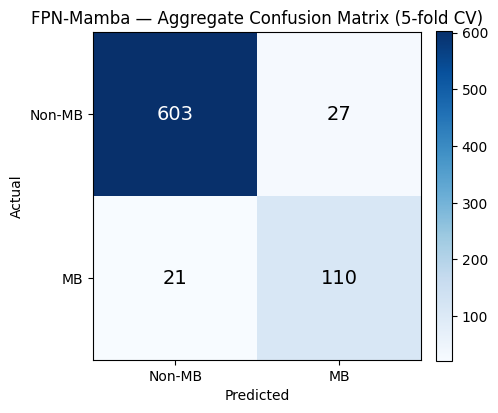

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(FPN_RESULTS) as f:
    fpn = json.load(f)

agg = fpn['aggregate_confusion_matrix']
tp, tn, fp, fn = agg['tp'], agg['tn'], agg['fp'], agg['fn']

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print('=== FPN-Mamba Aggregate Confusion Matrix (5-fold held-out, calibration-selected thresholds) ===')
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'  Sensitivity = {sensitivity:.4f}')
print(f'  Specificity = {specificity:.4f}')
print('  (Compare against the mean sensitivity/specificity printed in Cell 10 --')
print('   both are derived from the same per-fold calibration-thresholded predictions.)')

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-MB', 'MB'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Non-MB', 'MB'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('FPN-Mamba — Aggregate Confusion Matrix (5-fold CV)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

FIG2_PATH = f'{DRIVE_RESULTS}/figure2_confusion_matrix.png'
fig.savefig(FIG2_PATH, dpi=200)
print(f'\nSaved -> {FIG2_PATH}')
plt.show()

## Cell 13 — Verify Drive (all checkpoints saved)

In [ ]:
import os

def check(path, label):
    ok   = os.path.exists(path)
    size = f'{os.path.getsize(path)/1024:.0f} KB' if ok else ''
    print(f"  {'[OK]' if ok else '[MISSING]':<10} {label:<40} {size}")

print('=== Drive Contents ===')
check(BASELINE_RESULTS, 'InceptentionNet cv_results.json')
check(RESNET_RESULTS,   'ResNet-50 cv_results.json')
check(FPN_RESULTS,      'FPN-Mamba cv_results.json')
check(ABL_RESULTS,      'Ablation summary.json')
for run_name, run_dir in [('InceptentionNet', BASELINE_RUN_DIR), ('ResNet-50', RESNET_RUN_DIR), ('FPN-Mamba', FPN_RUN_DIR)]:
    for fold in range(1, 6):
        check(f'{run_dir}/fold_{fold}.pt', f'{run_name} fold_{fold}.pt')
    check(f'{run_dir}/best_model.pt', f'{run_name} best_model.pt')

## Cell 14 — Commit Results to Git

Copies each model's `cv_results.json` (and the ablation summary + per-variant
results) from Drive into `experiments/runs/<model>/` inside the cloned repo and
commits them. This is the step that was skipped for ResNet-50 last time, which is
why Table 1's std-dev cells for it went missing — the manuscript was typed up from
a Drive-only printout instead of a committed, reproducible `cv_results.json`.

Does **not** push automatically — review the commit, then run the printed
`git push` command yourself.

In [ ]:
import shutil, os, subprocess

COMMIT_TARGETS = {
    'inceptentionnet': (BASELINE_RUN_DIR, f'{REPO_DIR}/experiments/runs/inceptentionnet'),
    'resnet50':        (RESNET_RUN_DIR,   f'{REPO_DIR}/experiments/runs/resnet50'),
    'fpn_mamba':       (FPN_RUN_DIR,      f'{REPO_DIR}/experiments/runs/fpn_mamba'),
}

os.chdir(REPO_DIR)
added_paths = []
for name, (drive_dir, repo_dir) in COMMIT_TARGETS.items():
    src = f'{drive_dir}/cv_results.json'
    if not os.path.exists(src):
        print(f'  [MISSING] {name}: {src} not found -- run its training cell first.')
        continue
    os.makedirs(repo_dir, exist_ok=True)
    dst = f'{repo_dir}/cv_results.json'
    shutil.copyfile(src, dst)
    added_paths.append(dst)
    print(f'  [COPIED] {src} -> {dst}')

# Ablation: the summary table plus each variant's own cv_results.json
# (includes 'efficientnet_only' == EfficientNet-B2+GAP in the paper).
abl_root_drive = ABL_RUN_DIR
abl_root_repo  = f'{REPO_DIR}/experiments/runs/ablation'
if os.path.exists(f'{abl_root_drive}/ablation_summary.json'):
    os.makedirs(abl_root_repo, exist_ok=True)
    shutil.copyfile(f'{abl_root_drive}/ablation_summary.json', f'{abl_root_repo}/ablation_summary.json')
    added_paths.append(f'{abl_root_repo}/ablation_summary.json')
    for variant in ['efficientnet_only', 'fpn_standard', 'fpn_locality', 'fpn_cross_mamba', 'fpn_mamba_full']:
        src = f'{abl_root_drive}/{variant}/cv_results.json'
        if os.path.exists(src):
            dst_dir = f'{abl_root_repo}/{variant}'
            os.makedirs(dst_dir, exist_ok=True)
            dst = f'{dst_dir}/cv_results.json'
            shutil.copyfile(src, dst)
            added_paths.append(dst)
            print(f'  [COPIED] {src} -> {dst}')
else:
    print(f'  [MISSING] ablation: {abl_root_drive}/ablation_summary.json not found -- run the ablation cell first.')

if added_paths:
    rel_paths = [os.path.relpath(p, REPO_DIR) for p in added_paths]
    subprocess.run(['git', 'add'] + rel_paths, check=True)
    status = subprocess.run(['git', 'status', '--short'] + rel_paths, capture_output=True, text=True).stdout
    print('\ngit status (staged):\n', status)
    subprocess.run(['git', 'commit', '-m',
                     'Add post-leakage-fix cv_results.json for all four models (5-fold CV, calibration-split protocol)'],
                    check=True)
    print('\nCommitted locally. Review with `git log -1 -p`, then push yourself:')
    print(f'  cd {REPO_DIR} && git push origin {BRANCH}')
else:
    print('\nNothing to commit -- no cv_results.json files were found.')

## Cell 15 — Diagnostic: Calibration Split Size & Per-Fold Threshold Instability

Investigates why precision (and cross-fold std) got noticeably worse after the
leakage fix, especially for InceptentionNet and ResNet-50. Two parts:

1. **Split composition** — rebuilds the exact same StratifiedKFold + calibration
   splits `run_crossval()` uses (no training, no GPU, seconds to run) and prints how
   many MB-positive examples actually end up in each fold's calibration set. With
   ~131 (or 106) total MB images split 5 ways and then 15% further split off for
   calibration, that number can drop to ~13–16 positives — too few to pin down a
   stable Youden's-J threshold.
2. **Threshold audit** — for each already-trained model, prints every fold's
   `calibration_threshold` next to its held-out confusion matrix. `find_best_threshold`
   clips to `[0.30, 0.85]`; a threshold sitting exactly on one of those rails is a
   strong signal that the calibration ROC estimate was too noisy to land on an
   interior value — pinned-low thresholds over-predict positive (precision craters),
   pinned-high thresholds under-predict positive (recall/sensitivity craters).

Run this after Cells 6–9 have produced `cv_results.json` for whichever models you
want to inspect.

In [ ]:
import json
import numpy as np
import yaml
from sklearn.model_selection import StratifiedKFold

from src.data.dataset import build_binary_samples
from src.training.trainer import _make_calibration_split

CONFIGS = {
    'InceptentionNet': f'{REPO_DIR}/configs/inceptentionnet.yaml',
    'ResNet-50':       f'{REPO_DIR}/configs/resnet50.yaml',
    'FPN-Mamba':       f'{REPO_DIR}/configs/fpn_mamba.yaml',
    'Ablation':        f'{REPO_DIR}/configs/ablation.yaml',
}

RESULTS = {
    'InceptentionNet': BASELINE_RESULTS,
    'ResNet-50':       RESNET_RESULTS,
    'FPN-Mamba':       FPN_RESULTS,
}

print('=' * 78)
print('PART 1 -- Calibration split composition (no training, recomputed live)')
print('=' * 78)
for name, cfg_path in CONFIGS.items():
    cfg = yaml.safe_load(open(cfg_path, encoding='utf-8'))
    samples = build_binary_samples(
        data_root=cfg['data']['data_root'],
        mb_class_name=cfg['data'].get('mb_class_name', 'Meduloblastoma'),
        mb_target_count=cfg['data'].get('mb_target_count', 131),
        non_mb_target_count=cfg['data'].get('non_mb_target_count', 630),
        seed=cfg.get('seed', 42),
        deduplicate=cfg['data'].get('deduplicate', True),
    )
    labels = np.array([s.label for s in samples])
    calib_frac = cfg['training'].get('calibration_fraction', 0.15)
    min_calib_pos = cfg['training'].get('min_calibration_positives', 20)
    max_calib_frac = cfg['training'].get('max_calibration_fraction', 0.30)
    print(f"\n{name}  (n={len(samples)}, MB={int(labels.sum())}, "
          f"non-MB={int(len(labels) - labels.sum())}, calibration_fraction={calib_frac}, "
          f"min_calibration_positives={min_calib_pos})")
    splitter = StratifiedKFold(
        n_splits=cfg['training'].get('num_folds', 5), shuffle=True,
        random_state=cfg.get('seed', 42),
    )
    for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(np.zeros(len(samples)), labels)):
        tr = [samples[i] for i in tr_idx]
        va_labels = labels[va_idx]
        inner, calib, eff_frac = _make_calibration_split(
            tr, calib_frac, seed=cfg.get('seed', 42) + fold_idx,
            min_calib_positives=min_calib_pos, max_calib_fraction=max_calib_frac,
        )
        calib_labels = np.array([s.label for s in calib])
        inner_labels = np.array([s.label for s in inner])
        n_calib_pos = int(calib_labels.sum())
        flag = '  <-- still below floor (positives exhausted by max_calibration_fraction cap)' if n_calib_pos < min_calib_pos else ''
        print(f'  fold {fold_idx + 1}: inner={len(inner):>4} (MB={int(inner_labels.sum()):>3})   '
              f'calib={len(calib):>3} (MB={n_calib_pos:>3}, eff_frac={eff_frac:.3f})   '
              f'held-out={len(va_idx):>4} (MB={int(va_labels.sum()):>3}){flag}')

print('\n' + '=' * 78)
print('PART 2 -- Per-fold threshold audit (from already-trained cv_results.json)')
print('=' * 78)
for name, path in RESULTS.items():
    import os
    if not os.path.exists(path):
        print(f'\n{name}: {path} not found -- train it first.')
        continue
    with open(path) as f:
        payload = json.load(f)
    print(f'\n{name}:')
    for fr in payload['fold_results']:
        m = fr['metrics']
        thr = m.get('calibration_threshold', float('nan'))
        thr_std = m.get('calibration_threshold_std', float('nan'))
        n_calib_pos = m.get('calibration_num_positives', '?')
        rail = ''
        if abs(thr - 0.30) < 1e-6:
            rail = '  <-- PINNED AT LOWER RAIL (0.30)'
        elif abs(thr - 0.85) < 1e-6:
            rail = '  <-- PINNED AT UPPER RAIL (0.85)'
        print(f"  fold {fr['fold']}: thr={thr:.4f} (bootstrap std={thr_std:.4f}, calib_positives={n_calib_pos}){rail}\n"
              f"    held-out TP={m.get('tp')} TN={m.get('tn')} FP={m.get('fp')} FN={m.get('fn')}   "
              f"precision={m['precision']:.4f}  recall={m['recall']:.4f}  "
              f"sens={m['sensitivity']:.4f}  spec={m['specificity']:.4f}  auc={m['auc']:.4f}")